In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

main_path = '/Users/Kai/HPL-LATTICeA'
sys.path.append(main_path)

In [2]:
def plot_forest(
    feature_names,
    estimates,
    ci_lower,
    ci_upper,
    p_values,
    *,
    reference=1.0,
    x_label="Hazard ratio (95% CI)",
    marker_kwargs=None,
    error_kwargs=None,
    table_headers=("95% CI", "p"),
    figsize=None,
):
    feature_names = list(feature_names)
    n_features = len(feature_names)

    estimates = np.asarray(estimates, dtype=float)
    ci_lower = np.asarray(ci_lower, dtype=float)
    ci_upper = np.asarray(ci_upper, dtype=float)
    p_values = np.asarray(p_values, dtype=float)

    if not (len(estimates) == len(ci_lower) == len(ci_upper) == len(p_values) == n_features):
        raise ValueError("All input arrays must match feature_names length.")

    if figsize is None:
        figsize = (7, 0.45 * n_features + 1.5)

    default_marker = {"fmt": "s", "color": "black", "markersize": 6, "mec": "black"}
    default_error = {"ecolor": "black", "elinewidth": 1.4, "capsize": 3, "capthick": 1.2}
    marker_kwargs = {**default_marker, **(marker_kwargs or {})}
    error_kwargs = {**default_error, **(error_kwargs or {})}

    fig, axes_arr = plt.subplots(
        ncols=2,
        sharey=True,
        figsize=figsize,
        gridspec_kw={"width_ratios": [0.7, 0.3]},
    )
    ax_forest, ax_table = axes_arr

    y_positions = np.arange(n_features)[::-1]

    # Middle forest plot
    error_offsets = np.vstack([estimates - ci_lower, ci_upper - estimates])
    ax_forest.errorbar(estimates, y_positions, xerr=error_offsets, **marker_kwargs, **error_kwargs)
    ax_forest.axvline(reference, color="grey", linewidth=1.15, linestyle="--")
    ax_forest.set_xlabel(x_label)
    ax_forest.set_yticks(y_positions)
    ax_forest.set_yticklabels(feature_names)
    ax_forest.set_ylim(-0.5, n_features - 0.5)
    ax_forest.set_xlim([min(ci_lower) - 0.2, max(ci_upper) + 0.2])
    ax_forest.set_ylabel('Cluster')

    for ax in [ax_forest]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_visible(True)
        ax.spines["left"].set_visible(False)

    # Right: two-column text (CI | p-value)
    def format_interval(lo, hi):
        return f"({lo:.2f} – {hi:.2f})"

    def format_p(p):
        if np.isnan(p):
            return "NA"
        if p < 0.001:
            return "<0.001"
        return f"{p:.3f}"

    ax_table.set_xlim(0, 1)
    ax_table.set_ylim(-0.5, n_features - 0.5)
    ax_table.axis("off")

    ci_x, p_x = 0.1, 0.75  # tweak to taste

    ax_table.text(ci_x, n_features - 0.3, table_headers[0], va="bottom", ha="center", fontsize=11, fontweight="bold")
    ax_table.text(p_x, n_features - 0.3, table_headers[1], va="bottom", ha="center", fontsize=11, fontweight="bold")

    for y, lo, hi, p in zip(y_positions, ci_lower, ci_upper, p_values):
        ax_table.text(ci_x, y, format_interval(lo, hi), va="center", ha="center", fontsize=10)
        ax_table.text(p_x, y, format_p(p), va="center", ha="center", fontsize=10)

    fig.tight_layout()
    return fig, {"forest": ax_forest, "table": ax_table}
    # return fig, {"labels": ax_labels, "forest": ax_forest, "table": ax_table}


In [ ]:
import matplotlib as mpl
import seaborn as sns

sns.set_context("paper", font_scale=1.5)

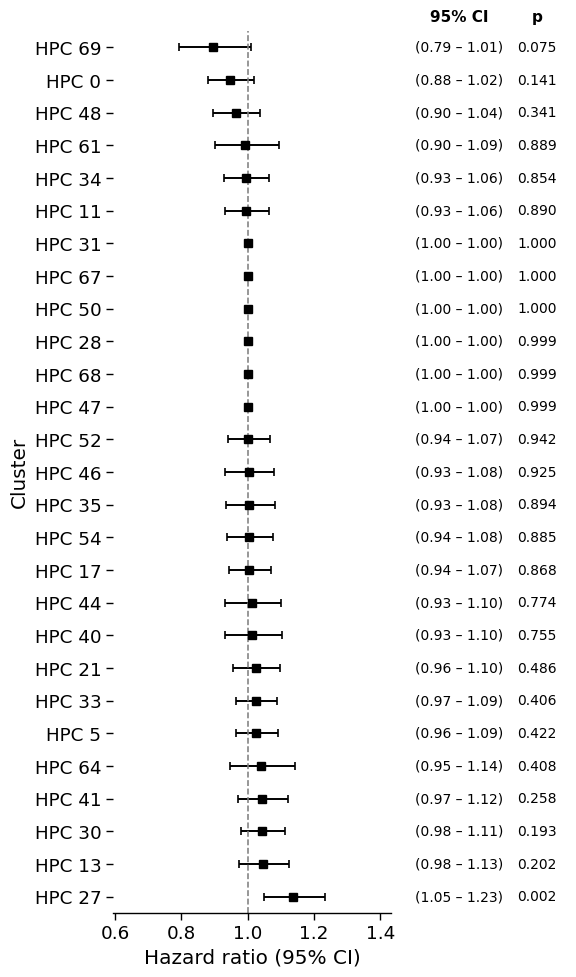

In [9]:
os_tumour = pd.read_csv(os.path.join(main_path, 'data/vanilla-hpc/os_event_ind_fold_0_tumour.csv'))
os_tumour['covariate'] = [f'HPC {c}' for c in os_tumour['covariate']]
results_dir = os.path.join(main_path, 'data/vanilla-hpc')

plot_forest(feature_names=os_tumour['covariate'],
                estimates=os_tumour['exp(coef)'],
                ci_lower=os_tumour['exp(coef) lower 95%'],
                ci_upper=os_tumour['exp(coef) upper 95%'],
                p_values=os_tumour['p'],
                figsize=(6,10))
    
plt.savefig(os.path.join(main_path, results_dir, f'os_fold_0_tumour_hpc.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

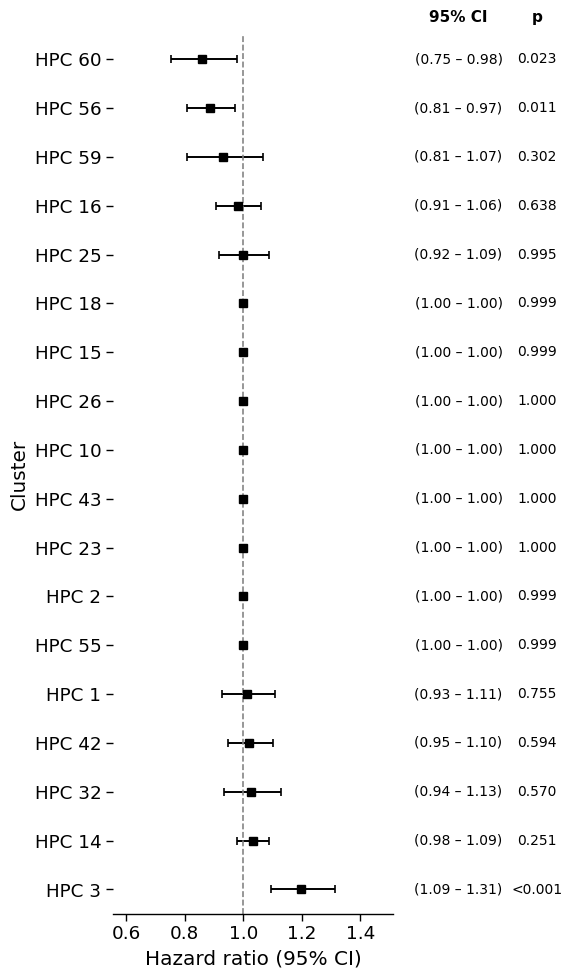

In [8]:
os_stroma = pd.read_csv(os.path.join(main_path, 'data/vanilla-hpc/os_event_ind_fold_0_stroma.csv'))

os_stroma['covariate'] = [f'HPC {c}' for c in os_stroma['covariate']]
results_dir = os.path.join(main_path, 'data/vanilla-hpc')

plot_forest(feature_names=os_stroma['covariate'],
                estimates=os_stroma['exp(coef)'],
                ci_lower=os_stroma['exp(coef) lower 95%'],
                ci_upper=os_stroma['exp(coef) upper 95%'],
                p_values=os_stroma['p'],
                figsize=(6,10))
    
plt.savefig(os.path.join(main_path, results_dir, f'os_fold_0_stroma_hpc.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

In [11]:
c_index_df_tumour = pd.read_csv(os.path.join(main_path, 'analysis/clinical-and-survival/hpc-survival/Tumour model/folds_data/c_indexes.csv'))
c_index_df_stroma = pd.read_csv(os.path.join(main_path, 'analysis/clinical-and-survival/hpc-survival/Stroma model/folds_data/c_indexes.csv'))
c_index_df_all = pd.read_csv(os.path.join(main_path, 'analysis/clinical-and-survival/hpc-survival/All model/c_indexes.csv'))